In [ ]:
# SECTION 1: IMPORTS & CONFIGURATION


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os, sys

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_score,
    learning_curve, RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter optimisation
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# PSO for SVM (fallback if unavailable)
try:
    import pyswarms as ps
    PSO_AVAILABLE = True
except ImportError:
    PSO_AVAILABLE = False

# Interpretability
import shap

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.4 MB/s eta 0:00:00


In [ ]:
# SECTION 2: DATA LOADING


df = pd.read_csv('/content/diabetes_prediction_dataset.csv')
print(f'Original shape: {df.shape}')
print('First 5 rows:')
display(df.head())

Original shape: (100000, 9)
First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


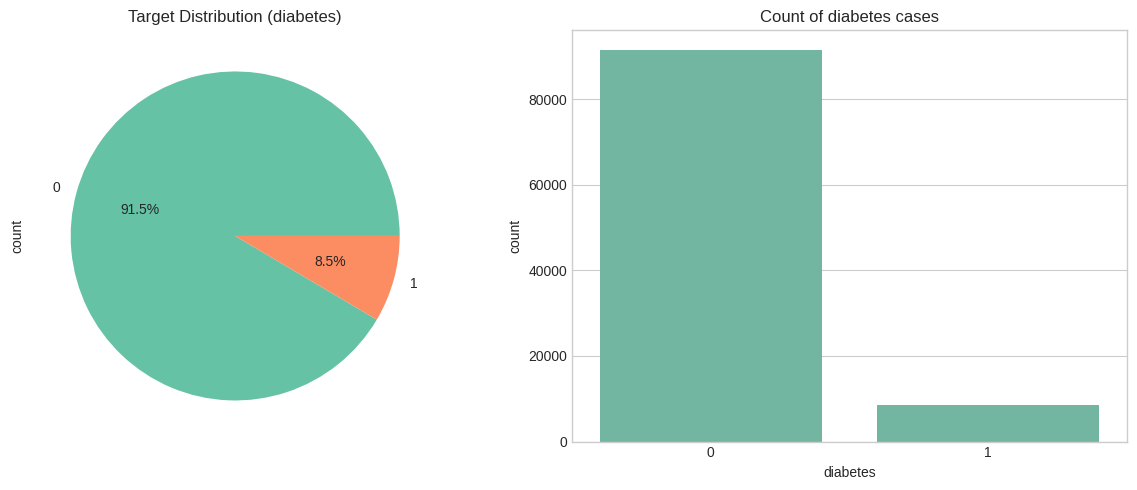

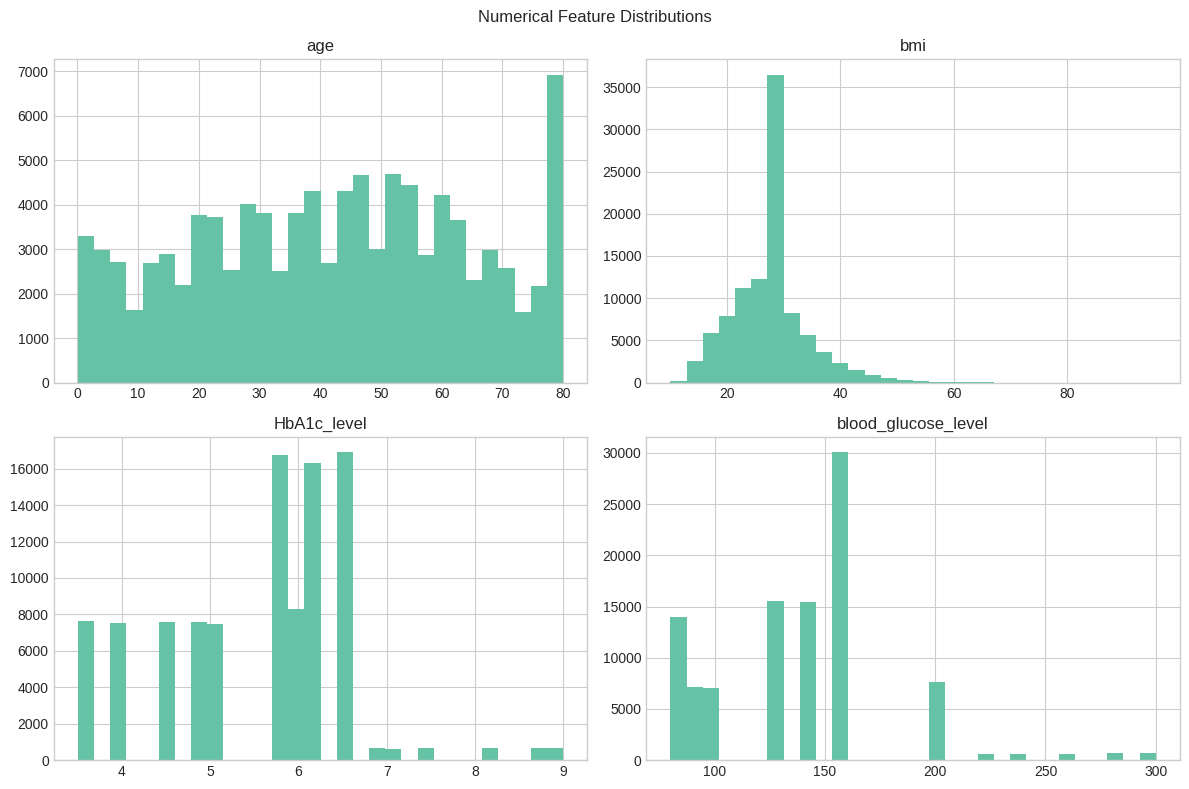

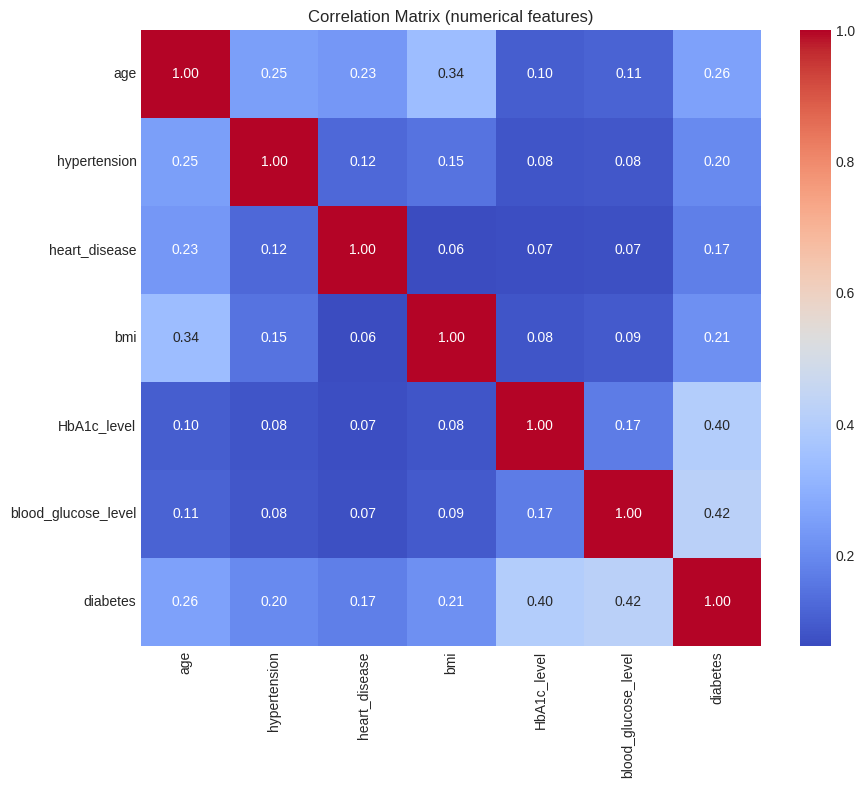

In [ ]:
# SECTION 3: EXPLORATORY DATA ANALYSIS


# Basic info
print('Data types and missing values:')
df.info()

# Class distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df['diabetes'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Target Distribution (diabetes)')
sns.countplot(data=df, x='diabetes', ax=ax[1])
ax[1].set_title('Count of diabetes cases')
plt.tight_layout()
plt.show()

# Numerical feature distributions
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric features only)
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (numerical features)')
plt.show()

In [ ]:
print(df['gender'].unique())

['Female' 'Male' 'Other']



Removed 3854 duplicate rows.
After removing duplication: (96146, 9)
After domain filtering: (96134, 9)


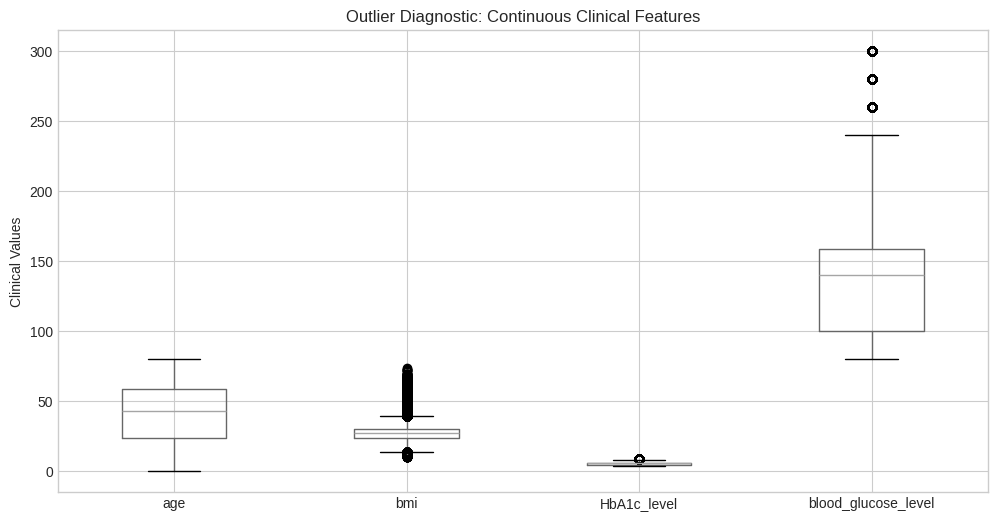

In [ ]:
# SECTION 4:DATA CLEANING & ANOMALY DETECTION




# 4.1 Deduplication

dup_count = df.duplicated().sum()
if dup_count:
    df = df.drop_duplicates()
    print(f"\nRemoved {dup_count} duplicate rows.")
print(f"After removing duplication: {df.shape}")


# 4.3 Domain-Specific Filtering

df = df[df['age'].between(0, 110)]
df = df[df['bmi'].between(10, 75)]
df = df[df['HbA1c_level'].between(3.0, 16.0)]
df = df[df['blood_glucose_level'].between(30, 550)]
print(f"After domain filtering: {df.shape}")





# 4.5. OUTLIER DETECTION


num_features = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

plt.figure(figsize=(12,6))

df[num_features].boxplot()

plt.title(
    'Outlier Diagnostic: Continuous Clinical Features'
)

plt.ylabel('Clinical Values')

plt.show()



In [ ]:
# SECTION 5: SPLIT & PREPROCESSING


X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, stratify=y_train_full,
    random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

# Feature groups
num_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
cat_features = ['gender', 'smoking_history']
bin_features = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),
    ('bin', 'passthrough', bin_features)
])
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f'Processed feature count: {X_train_proc.shape[1]}')



# SECTION 5.5: CLINICAL FEATURE ENGINEERING (LR & NB)

def create_clinical_features(X_raw):
    X_extra = pd.DataFrame(index=X_raw.index)
    X_extra['hba1c_diabetes_range']       = (X_raw['HbA1c_level'] >= 6.5).astype(int)
    X_extra['glucose_diabetes_range']     = (X_raw['blood_glucose_level'] >= 200).astype(int)
    X_extra['both_hba1c_and_glucose_high']= ((X_raw['HbA1c_level'] >= 6.5) & (X_raw['blood_glucose_level'] >= 200)).astype(int)
    X_extra['either_hba1c_or_glucose_high']=((X_raw['HbA1c_level'] >= 6.5) | (X_raw['blood_glucose_level'] >= 200)).astype(int)
    X_extra['hba1c_prediabetes_range']    = (X_raw['HbA1c_level'] >= 5.7).astype(int)
    X_extra['glucose_high_range']         = (X_raw['blood_glucose_level'] >= 140).astype(int)
    X_extra['bmi_obese']                  = (X_raw['bmi'] >= 30).astype(int)
    X_extra['age_high_risk']              = (X_raw['age'] >= 45).astype(int)
    X_extra['hba1c_glucose_interaction']  = X_raw['HbA1c_level'] * X_raw['blood_glucose_level']
    X_extra['age_bmi_interaction']        = X_raw['age'] * X_raw['bmi']
    X_extra['risk_count'] = (
        (X_raw['HbA1c_level'] >= 6.5).astype(int) +
        (X_raw['blood_glucose_level'] >= 200).astype(int) +
        (X_raw['bmi'] >= 30).astype(int) +
        (X_raw['age'] >= 45).astype(int) +
        X_raw['hypertension'].astype(int) +
        X_raw['heart_disease'].astype(int)
    )
    return X_extra

clinical_scaler = StandardScaler()
X_train_extra = create_clinical_features(X_train)
X_val_extra   = create_clinical_features(X_val)
X_test_extra  = create_clinical_features(X_test)

clinical_scaler.fit(X_train_extra)
X_train_extra_scaled = clinical_scaler.transform(X_train_extra)
X_val_extra_scaled   = clinical_scaler.transform(X_val_extra)
X_test_extra_scaled  = clinical_scaler.transform(X_test_extra)

# Combine enhanced features with standard processed data
X_train_lrnb = np.hstack([X_train_proc, X_train_extra_scaled]).astype(np.float32)
X_val_lrnb   = np.hstack([X_val_proc,   X_val_extra_scaled]).astype(np.float32)
X_test_lrnb  = np.hstack([X_test_proc,  X_test_extra_scaled]).astype(np.float32)

print(f'LR/NB enhanced train shape: {X_train_lrnb.shape}')

Train: (67290, 8), Val: (14423, 8), Test: (14421, 8)
Processed feature count: 13
LR/NB enhanced train shape: (67290, 24)


In [ ]:
# SECTION 6: SMOTE (FIXED RATIO 0.7)


from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.7, random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts())
print("After SMOTE:", pd.Series(y_train_bal).value_counts())
print("X_train_bal shape:", X_train_bal.shape)

Before SMOTE: diabetes
0    61356
1     5934
Name: count, dtype: int64
After SMOTE: diabetes
0    61356
1    42949
Name: count, dtype: int64
X_train_bal shape: (104305, 13)


In [ ]:
# SECTION 7: PCA PREPARATION


from sklearn.decomposition import PCA

pca = PCA(n_components=5, random_state=RANDOM_STATE)
pca.fit(X_train_bal)

X_train_bal_pca = pca.transform(X_train_bal)
X_val_pca       = pca.transform(X_val_proc)
X_test_pca      = pca.transform(X_test_proc)

print(f"Explained variance by 5 components: {pca.explained_variance_ratio_.sum():.3f}")
print("Per‑component ratios:", np.round(pca.explained_variance_ratio_, 3))

Explained variance by 5 components: 0.894
Per‑component ratios: [0.399 0.182 0.159 0.11  0.044]


In [ ]:
# SECTION 8: HYPERPARAMETER OPTIMISATION
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score

In [ ]:
# SECTION 8.0: THRESHOLD OPTIMISER HELPER


def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.001, 0.999, 999)
    best_thr = 0.5
    best_f1 = 0
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = thr
    return best_thr, best_f1

sampler = SMOTE(sampling_strategy=0.7, random_state=RANDOM_STATE)

In [ ]:
# 8.1 Logistic Regression – manual grid + threshold


lr_candidates = []
for C in [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]:
    for solver in ['lbfgs', 'liblinear']:
        penalties = ['l2'] if solver == 'lbfgs' else ['l1', 'l2']
        for penalty in penalties:
            model = LogisticRegression(C=C, solver=solver, penalty=penalty,
                                       max_iter=10000, class_weight=None,
                                       random_state=RANDOM_STATE)
            model.fit(X_train_lrnb, y_train)
            y_val_prob = model.predict_proba(X_val_lrnb)[:, 1]
            thr, val_f1 = find_best_threshold(y_val, y_val_prob)
            lr_candidates.append({'C': C, 'solver': solver, 'penalty': penalty,
                                  'threshold': thr, 'f1': val_f1})

best_lr = max(lr_candidates, key=lambda x: x['f1'])
logreg_params = {'C': best_lr['C'], 'solver': best_lr['solver'],
                 'penalty': best_lr['penalty']}
logreg_threshold = best_lr['threshold']
print(f"LR best: {logreg_params}, threshold={logreg_threshold:.4f}, val F1={best_lr['f1']:.4f}")

LR best: {'C': 100, 'solver': 'lbfgs', 'penalty': 'l2'}, threshold=0.3850, val F1=0.7574


In [ ]:
# 8.2 Gaussian NB – var_smoothing grid + threshold


nb_candidates = []
for var_smoothing in [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]:
    model = GaussianNB(var_smoothing=var_smoothing)
    model.fit(X_train_lrnb, y_train)
    y_val_prob = model.predict_proba(X_val_lrnb)[:, 1]
    thr, val_f1 = find_best_threshold(y_val, y_val_prob)
    nb_candidates.append({'var_smoothing': var_smoothing, 'threshold': thr,
                          'f1': val_f1})

best_nb = max(nb_candidates, key=lambda x: x['f1'])
nb_params = {'var_smoothing': best_nb['var_smoothing']}
nb_threshold = best_nb['threshold']
print(f"Gaussian NB best: {nb_params}, threshold={nb_threshold:.4f}, val F1={best_nb['f1']:.4f}")

Gaussian NB best: {'var_smoothing': 0.01}, threshold=0.9990, val F1=0.6275


In [ ]:
# 8.3 SVM RBF – PSO + GridSearch

# Re‑use the SMOTE sampler (ratio 0.7) for internal CV
sampler = SMOTE(sampling_strategy=0.7, random_state=RANDOM_STATE)

# ----- PSO (if available) -----
try:
    import pyswarms as ps
    PSO_AVAILABLE = True
except ImportError:
    PSO_AVAILABLE = False

if PSO_AVAILABLE:
    def svm_objective(params):
        C = params[:, 0]
        gamma = params[:, 1]
        scores = np.zeros(len(C))
        for i in range(len(C)):
            clf = SVC(C=C[i], gamma=gamma[i], kernel='rbf', probability=True,
                      random_state=RANDOM_STATE)
            pipe = ImbPipeline([('sampler', sampler), ('clf', clf)])
            score = cross_val_score(pipe, X_train_proc, y_train,
                                    scoring='f1', cv=2, n_jobs=-1).mean()
            scores[i] = -score
        return scores

    bounds = (np.array([0.1, 0.001]), np.array([10.0, 1.0]))
    options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
    optimizer = ps.single.GlobalBestPSO(n_particles=8, dimensions=2,
                                        options=options, bounds=bounds)
    best_cost, best_pos = optimizer.optimize(svm_objective, iters=15)
    svm_pso_params = {'C': best_pos[0], 'gamma': best_pos[1]}
    svm_pso_score = -best_cost
    print(f"PSO best: {svm_pso_params}, F1={svm_pso_score:.4f}")
else:
    svm_pso_params = None
    svm_pso_score = -1

# ----- GridSearchCV -----
param_grid = {'clf__C': [0.1, 0.5, 1, 5, 10],
              'clf__gamma': [0.001, 0.01, 0.1, 0.5, 1.0]}
svm_pipe = ImbPipeline([
    ('sampler', sampler),
    ('clf', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
])
grid_search = GridSearchCV(svm_pipe, param_grid, scoring='f1', cv=2,
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train_proc, y_train)
svm_gs_params = {k.replace('clf__', ''): v for k, v in grid_search.best_params_.items()}
svm_gs_score = grid_search.best_score_
print(f"GridSearch best: {svm_gs_params}, F1={svm_gs_score:.4f}")

# Choose best
if svm_pso_params is not None and svm_pso_score > svm_gs_score:
    svm_best_params = svm_pso_params
    print("Using PSO result.")
else:
    svm_best_params = svm_gs_params
    print("Using GridSearch result.")

GridSearch best: {'C': 5, 'gamma': 0.5}, F1=0.6603
Using GridSearch result.


In [ ]:
# 8.4 SVM Linear – Optuna


def objective_svm_linear(trial):
    C = trial.suggest_float('C', 0.01, 10, log=True)
    clf = SVC(C=C, kernel='linear', probability=True, random_state=RANDOM_STATE)
    pipe = ImbPipeline([('sampler', sampler), ('clf', clf)])
    return cross_val_score(pipe, X_train_proc, y_train, scoring='f1', cv=2, n_jobs=-1).mean()

study_svm_lin = optuna.create_study(direction='maximize')
study_svm_lin.optimize(objective_svm_linear, n_trials=8, show_progress_bar=False)
svm_linear_params = study_svm_lin.best_params
print(f"SVM Linear best: {svm_linear_params}, F1={study_svm_lin.best_value:.4f}")

SVM Linear best: {'C': 0.729239647448336}, F1=0.6258


In [ ]:
# 8.5 MLP – Optuna


def objective_mlp(trial):
    layers = trial.suggest_categorical('hidden_layer_sizes', [(64,32), (128,64)])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    lr_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    clf = MLPClassifier(hidden_layer_sizes=layers, alpha=alpha,
                        learning_rate_init=lr_init, max_iter=400,
                        early_stopping=True, random_state=RANDOM_STATE)
    pipe = ImbPipeline([('sampler', sampler), ('clf', clf)])
    return cross_val_score(pipe, X_train_proc, y_train, scoring='f1', cv=2, n_jobs=-1).mean()

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=12, show_progress_bar=False)
mlp_params = study_mlp.best_params
print(f"MLP best: {mlp_params}, F1={study_mlp.best_value:.4f}")

MLP best: {'hidden_layer_sizes': (128, 64), 'alpha': 2.3638449885019527e-05, 'learning_rate_init': 0.0047877893303210324}, F1=0.6858


In [ ]:
# 8.6 Random Forest – Optuna


def objective_rf(trial):
    n_est = trial.suggest_int('n_estimators', 100, 500, step=100)
    max_d = trial.suggest_int('max_depth', 3, 20)
    min_split = trial.suggest_int('min_samples_split', 2, 20)
    clf = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                 min_samples_split=min_split,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    pipe = ImbPipeline([('sampler', sampler), ('clf', clf)])
    return cross_val_score(pipe, X_train_proc, y_train, scoring='f1', cv=2, n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=12, show_progress_bar=False)
rf_params = study_rf.best_params
print(f"Random Forest best: {rf_params}, F1={study_rf.best_value:.4f}")

Random Forest best: {'n_estimators': 200, 'max_depth': 19, 'min_samples_split': 10}, F1=0.7624


In [ ]:
# 8.7 XGBoost – Optuna


def objective_xgb(trial):
    n_est = trial.suggest_int('n_estimators', 100, 500, step=100)
    max_d = trial.suggest_int('max_depth', 3, 10)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    clf = XGBClassifier(n_estimators=n_est, max_depth=max_d, learning_rate=lr,
                        use_label_encoder=False, eval_metric='logloss',
                        random_state=RANDOM_STATE, n_jobs=-1)
    pipe = ImbPipeline([('sampler', sampler), ('clf', clf)])
    return cross_val_score(pipe, X_train_proc, y_train, scoring='f1', cv=2, n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=12, show_progress_bar=False)
xgb_params = study_xgb.best_params
print(f"XGBoost best: {xgb_params}, F1={study_xgb.best_value:.4f}")

XGBoost best: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.048114622644015524}, F1=0.8090


In [ ]:
# SECTION 9: MODEL TRAINING & THRESHOLD TUNING

models = {}
model_feature_sets = {}

# Helper for SMOTE‑based models
def make_pipe(clf):
    return ImbPipeline([
        ('sampler', SMOTE(sampling_strategy=0.7, random_state=RANDOM_STATE)),
        ('clf', clf)
    ])

In [ ]:
# 9.1 Logistic Regression (enhanced features, no SMOTE)
models['Logistic Regression'] = LogisticRegression(
    **logreg_params, max_iter=10000, class_weight=None, random_state=RANDOM_STATE
)
models['Logistic Regression'].fit(X_train_lrnb, y_train)
model_feature_sets['Logistic Regression'] = {'train': X_train_lrnb, 'test': X_test_lrnb}
print("Logistic Regression trained.")

Logistic Regression trained.


In [ ]:
# 9.2 Gaussian NB (enhanced features, no SMOTE)
models['Gaussian NB'] = GaussianNB(**nb_params)
models['Gaussian NB'].fit(X_train_lrnb, y_train)
model_feature_sets['Gaussian NB'] = {'train': X_train_lrnb, 'test': X_test_lrnb}
print("Gaussian NB trained.")

Gaussian NB trained.


In [ ]:
# 9.3 – SVM Linear

models['SVM Linear'] = make_pipe(SVC(kernel='linear', **svm_linear_params,
                                     probability=True, random_state=RANDOM_STATE))
models['SVM Linear'].fit(X_train_proc, y_train)
model_feature_sets['SVM Linear'] = {'train': X_train_proc, 'test': X_test_proc}
print("SVM Linear trained.")

SVM Linear trained.


In [ ]:
# 9.4 – SVM RBF

models['SVM RBF'] = make_pipe(SVC(kernel='rbf', **svm_best_params,
                                  probability=True, random_state=RANDOM_STATE))
models['SVM RBF'].fit(X_train_proc, y_train)
model_feature_sets['SVM RBF'] = {'train': X_train_proc, 'test': X_test_proc}
print("SVM RBF trained.")

SVM RBF trained.


In [ ]:
#9.5 – MLP

models['MLP'] = make_pipe(MLPClassifier(**mlp_params, max_iter=400,
                                        early_stopping=True, random_state=RANDOM_STATE))
models['MLP'].fit(X_train_proc, y_train)
model_feature_sets['MLP'] = {'train': X_train_proc, 'test': X_test_proc}
print("MLP trained.")

MLP trained.


In [ ]:
# 9.6 – Random Forest

models['Random Forest'] = make_pipe(RandomForestClassifier(**rf_params,
                                                           random_state=RANDOM_STATE, n_jobs=-1))
models['Random Forest'].fit(X_train_proc, y_train)
model_feature_sets['Random Forest'] = {'train': X_train_proc, 'test': X_test_proc}
print("Random Forest trained.")

Random Forest trained.


In [ ]:
# 9.7 – XGBoost

models['XGBoost'] = make_pipe(XGBClassifier(**xgb_params, use_label_encoder=False,
                                            eval_metric='logloss',
                                            random_state=RANDOM_STATE, n_jobs=-1))
models['XGBoost'].fit(X_train_proc, y_train)
model_feature_sets['XGBoost'] = {'train': X_train_proc, 'test': X_test_proc}
print("XGBoost trained.")

XGBoost trained.


In [ ]:
# 9.8 Tuned thresholds for ALL models
model_thresholds = {}
for name, model in models.items():
    if name in ['Logistic Regression', 'Gaussian NB']:
        X_val_used = X_val_lrnb
    else:
        X_val_used = X_val_proc
    y_val_prob = model.predict_proba(X_val_used)[:, 1]
    best_thr, _ = find_best_threshold(y_val, y_val_prob)
    model_thresholds[name] = best_thr
    print(f"{name}: tuned threshold = {best_thr:.4f}")


Logistic Regression: tuned threshold = 0.3850
Gaussian NB: tuned threshold = 0.9990
SVM Linear: tuned threshold = 0.8600
SVM RBF: tuned threshold = 0.9080
MLP: tuned threshold = 0.9980
Random Forest: tuned threshold = 0.7530
XGBoost: tuned threshold = 0.5980


In [ ]:
# 9.9 Best model on validation (using tuned thresholds)
val_f1 = {}
for name, model in models.items():
    if name in ['Logistic Regression', 'Gaussian NB']:
        X_val_used = X_val_lrnb
    else:
        X_val_used = X_val_proc
    y_val_prob = model.predict_proba(X_val_used)[:, 1]
    y_val_pred = (y_val_prob >= model_thresholds[name]).astype(int)
    val_f1[name] = f1_score(y_val, y_val_pred)

best_model_name = max(val_f1, key=val_f1.get)
print(f"\nBest model (validation F1): {best_model_name} ({val_f1[best_model_name]:.4f})")


Best model (validation F1): XGBoost (0.7998)


In [ ]:
# 9.10 PCA version of the best model
if best_model_name not in ['Logistic Regression', 'Gaussian NB']:
    # Recreate the best model with its best params
    if best_model_name == 'SVM Linear':
        pca_clf = SVC(kernel='linear', **svm_linear_params, probability=True, random_state=RANDOM_STATE)
    elif best_model_name == 'SVM RBF':
        pca_clf = SVC(kernel='rbf', **svm_best_params, probability=True, random_state=RANDOM_STATE)
    elif best_model_name == 'MLP':
        pca_clf = MLPClassifier(**mlp_params, max_iter=400, early_stopping=True, random_state=RANDOM_STATE)
    elif best_model_name == 'Random Forest':
        pca_clf = RandomForestClassifier(**rf_params, random_state=RANDOM_STATE, n_jobs=-1)
    elif best_model_name == 'XGBoost':
        pca_clf = XGBClassifier(**xgb_params, use_label_encoder=False, eval_metric='logloss',
                                random_state=RANDOM_STATE, n_jobs=-1)
    else:
        pca_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

    pca_clf.fit(X_train_bal_pca, y_train_bal)
    models[f'{best_model_name} (PCA)'] = Pipeline([('clf', pca_clf)])
    model_feature_sets[f'{best_model_name} (PCA)'] = {'train': X_train_bal_pca, 'test': X_test_pca}
    # Tune threshold for PCA model as well
    y_val_pca_prob = models[f'{best_model_name} (PCA)'].predict_proba(X_val_pca)[:, 1]
    pca_thr, _ = find_best_threshold(y_val, y_val_pca_prob)
    model_thresholds[f'{best_model_name} (PCA)'] = pca_thr
    print(f"PCA model trained: {best_model_name} (PCA), threshold={pca_thr:.4f}")
else:
    print(f"PCA skipped for {best_model_name} (LR/NB).")

PCA model trained: XGBoost (PCA), threshold=0.7870


In [ ]:
# SECTION 10: EVALUATION ON TEST SET


def evaluate_model(name, model, X_test_data, y_test_data):
    y_proba = model.predict_proba(X_test_data)[:, 1]
    thr = model_thresholds[name]
    y_pred = (y_proba >= thr).astype(int)

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test_data, y_proba)
    pr_auc = average_precision_score(y_test_data, y_proba)
    cm = confusion_matrix(y_test_data, y_pred)

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Confusion Matrix': cm,
        'y_prob': y_proba,
        'y_test': y_test_data,
        'y_pred': y_pred,
        'threshold': thr
    }

results = []
for name, model in models.items():
    X_test_used = model_feature_sets[name]['test']
    res = evaluate_model(name, model, X_test_used, y_test)
    results.append(res)
    print(f"{name}: threshold={res['threshold']:.4f}, F1={res['F1-Score']:.4f}")

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k in [
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'
]} for r in results]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nModel Performance on Test Set (sorted by F1):")
display(metrics_df)

Logistic Regression: threshold=0.3850, F1=0.7487
Gaussian NB: threshold=0.9990, F1=0.6228
SVM Linear: threshold=0.8600, F1=0.7136
SVM RBF: threshold=0.9080, F1=0.7155
MLP: threshold=0.9980, F1=0.7900
Random Forest: threshold=0.7530, F1=0.7914
XGBoost: threshold=0.5980, F1=0.7910
XGBoost (PCA): threshold=0.7870, F1=0.7517

Model Performance on Test Set (sorted by F1):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.969212,0.983645,0.661950,0.791353,0.972406,0.864094
1,XGBoost,0.969004,0.975779,0.665094,0.791024,0.977414,0.880489
2,MLP,0.969004,0.981330,0.661164,0.790042,0.960232,0.835485
3,XGBoost (PCA),0.961237,0.864147,0.665094,0.751666,0.968903,0.844442
4,Logistic Regression,0.959920,0.837549,0.676887,0.748696,0.965712,0.835298
5,SVM RBF,0.957701,0.879587,0.602987,0.715485,0.960873,0.822760
6,SVM Linear,0.955412,0.823227,0.629717,0.713586,0.960070,0.805530
7,Gaussian NB,0.932044,0.610106,0.636006,0.622787,0.939615,0.588264


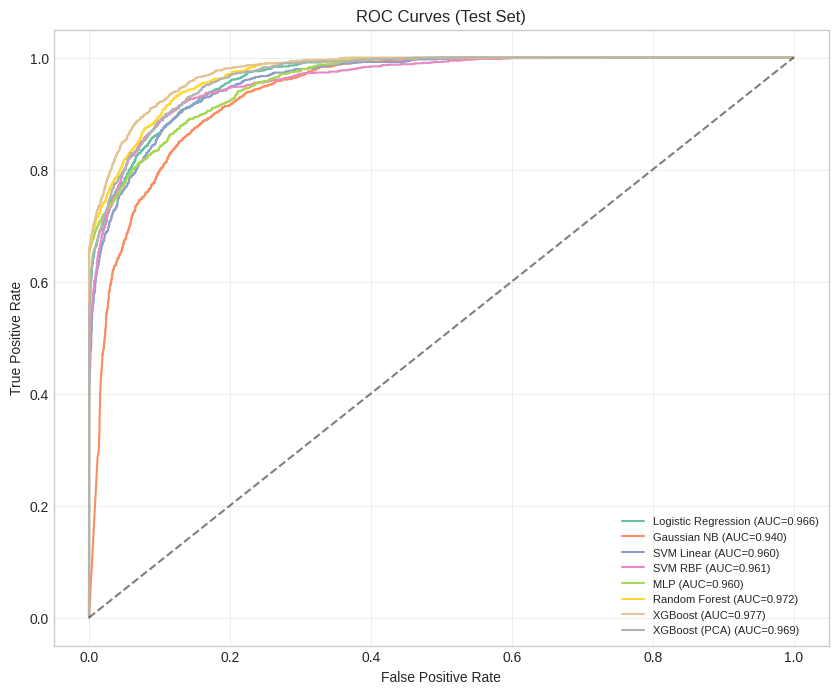

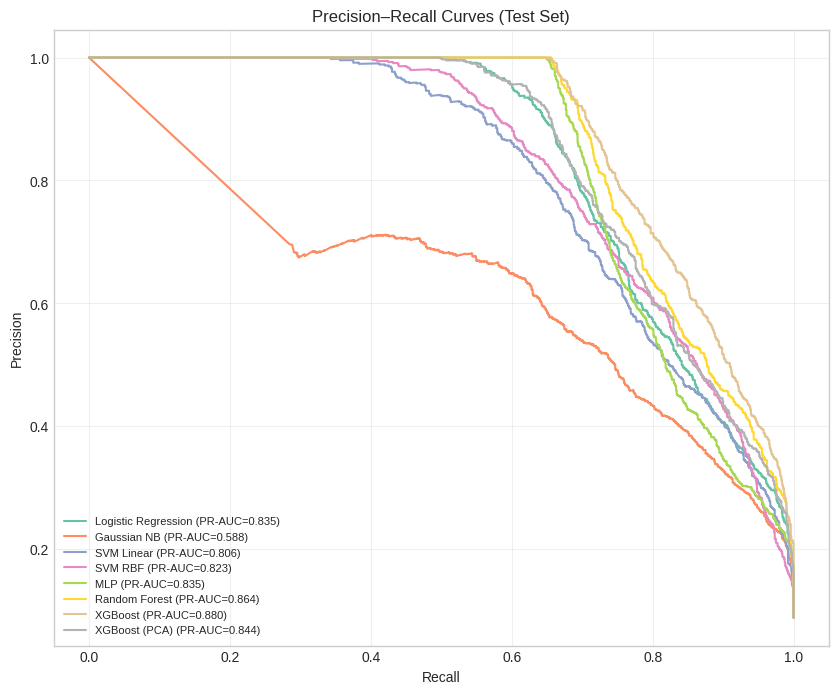

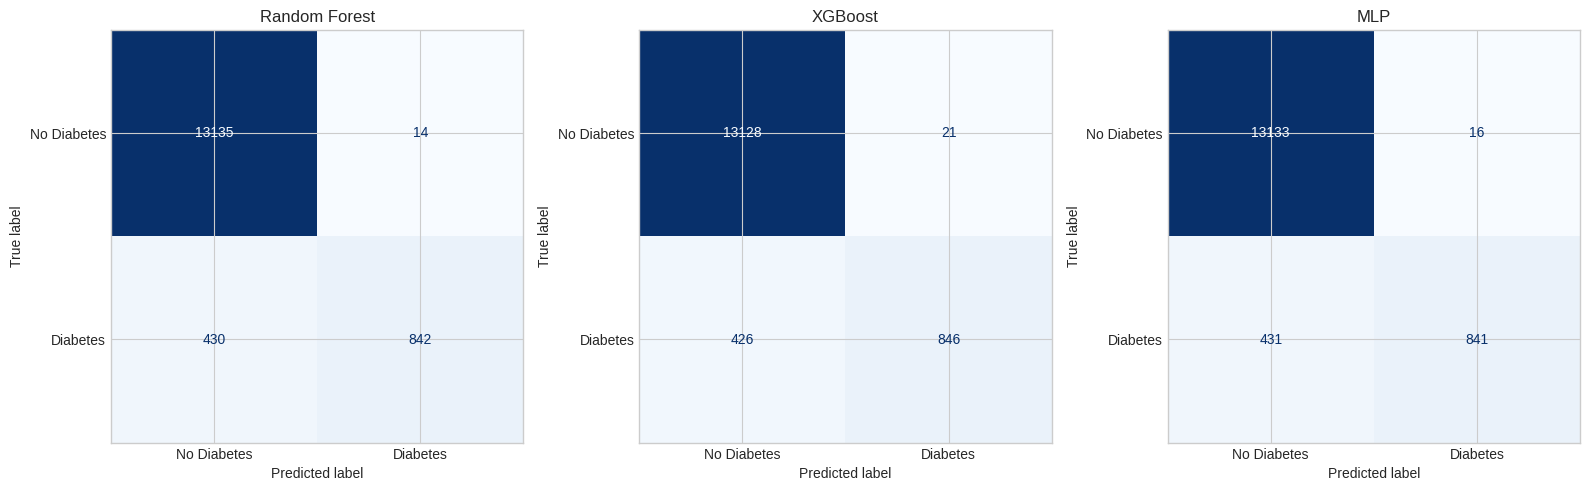

In [ ]:
# SECTION 12: ROC, PR CURVES & CONFUSION MATRICES


# ROC curves
plt.figure(figsize=(10, 8))
for res in results:
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_prob'])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Test Set)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

# PR curves
plt.figure(figsize=(10, 8))
for res in results:
    prec, rec, _ = precision_recall_curve(res['y_test'], res['y_prob'])
    plt.plot(rec, prec, label=f"{res['Model']} (PR-AUC={res['PR-AUC']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curves (Test Set)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

# Confusion matrices for top 3 models
top3 = metrics_df.head(3)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (_, row) in enumerate(top3.iterrows()):
    res = next(r for r in results if r['Model'] == row['Model'])
    ConfusionMatrixDisplay(res['Confusion Matrix'],
                           display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(row['Model'])
plt.tight_layout()
plt.show()

In [ ]:

# SECTION 13: LEARNING CURVES

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 7),
        n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Train')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.plot(train_sizes, val_mean, 's-', label='Validation')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
    plt.title(title)
    plt.xlabel('Training samples')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

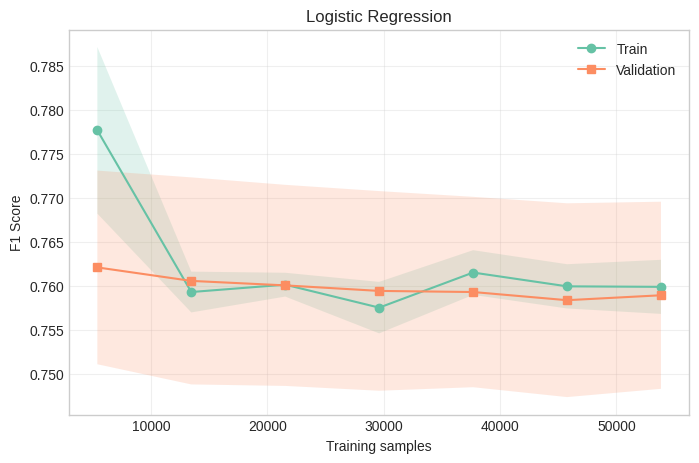

In [ ]:
# Learning curve – Logistic Regression
plot_learning_curve(models['Logistic Regression'], 'Logistic Regression',
                    X_train_lrnb, y_train, cv=5)

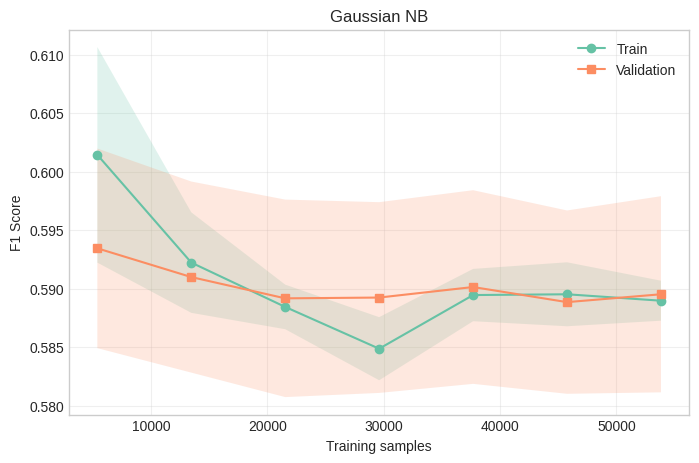

In [ ]:
# Learning curve – Gaussian NB
plot_learning_curve(models['Gaussian NB'], 'Gaussian NB',
                    X_train_lrnb, y_train, cv=5)

In [ ]:
# Learning curve – SVM Linear
plot_learning_curve(models['SVM Linear'], 'SVM Linear',
                    X_train_proc, y_train, cv=5)

In [ ]:
# Learning curve – SVM RBF
plot_learning_curve(models['SVM RBF'], 'SVM RBF',
                    X_train_proc, y_train, cv=5)

In [ ]:
# Learning curve – MLP
plot_learning_curve(models['MLP'], 'MLP',
                    X_train_proc, y_train, cv=5)

In [ ]:
# Learning curve – Random Forest
plot_learning_curve(models['Random Forest'], 'Random Forest',
                    X_train_proc, y_train, cv=5)

In [ ]:
# Learning curve – XGBoost
plot_learning_curve(models['XGBoost'], 'XGBoost',
                    X_train_proc, y_train, cv=5)

In [ ]:
# Learning curve – PCA version (if it exists)
if f'{best_model_name} (PCA)' in models:
    plot_learning_curve(models[f'{best_model_name} (PCA)'],
                        f'{best_model_name} (PCA)',
                        X_train_bal_pca, y_train_bal, cv=5)

In [ ]:
# SECTION 14: CALIBRATION ANALYSIS


from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 8))
for res in results:
    prob_true, prob_pred = calibration_curve(res['y_test'], res['y_prob'], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=res['Model'])
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagrams (Calibration Curves)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# SECTION 15: FEATURE IMPORTANCE & SHAP


# Get feature names after preprocessing
ohe = preprocessor.named_transformers_['cat']
cat_features_encoded = ohe.get_feature_names_out(cat_features)
all_features = num_features + list(cat_features_encoded) + bin_features

# For LR/NB we have additional clinical features – we'll show them if the best model is LR/NB
if best_model_name in ['Logistic Regression', 'Gaussian NB']:
    clinical_feature_names_list = [
        'hba1c_diabetes_range', 'glucose_diabetes_range', 'both_hba1c_and_glucose_high',
        'either_hba1c_or_glucose_high', 'hba1c_prediabetes_range', 'glucose_high_range',
        'bmi_obese', 'age_high_risk', 'hba1c_glucose_interaction',
        'age_bmi_interaction', 'risk_count'
    ]
    all_features = all_features + clinical_feature_names_list

# 1. Feature importance for tree-based models (if best model is RF/XGB)
if best_model_name in ['Random Forest', 'XGBoost']:
    clf = models[best_model_name].named_steps['clf']
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(10, 5))
    plt.title(f'{best_model_name} Feature Importances')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [all_features[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif best_model_name == 'Logistic Regression':
    clf = models[best_model_name]   # it's not a pipeline, it's the LR itself
    coef = clf.coef_[0]
    indices = np.argsort(np.abs(coef))[::-1][:10]
    plt.figure(figsize=(10, 5))
    plt.title(f'{best_model_name} Top Coefficients (absolute)')
    plt.barh(range(len(indices)), np.abs(coef[indices]), align='center')
    plt.yticks(range(len(indices)), [all_features[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 2. SHAP for best model (if applicable)
if best_model_name in ['Random Forest', 'XGBoost', 'Logistic Regression', 'SVM RBF']:
    X_shap = X_test_proc[:500]  # use a subset for speed
    if best_model_name in ['Random Forest', 'XGBoost']:
        model_shap = models[best_model_name].named_steps['clf']
        explainer = shap.TreeExplainer(model_shap)
    elif best_model_name == 'Logistic Regression':
        model_shap = models[best_model_name]
        explainer = shap.LinearExplainer(model_shap, X_train_lrnb[:500])
    elif best_model_name == 'SVM RBF':
        model_shap = models[best_model_name].named_steps['clf']
        explainer = shap.KernelExplainer(model_shap.predict_proba, X_train_proc[:200])
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, X_shap, feature_names=all_features, show=False)
    plt.title(f'SHAP Summary – {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not directly applicable; feature importance shown instead.")

In [ ]:
# SECTION 16: IMPACT OF PCA

if f'{best_model_name} (PCA)' in models:
    orig = next(r for r in results if r['Model'] == best_model_name)
    pca_res = next(r for r in results if r['Model'] == f'{best_model_name} (PCA)')
    print(f'IMPACT OF PCA ON {best_model_name}')
    print(f"Original -> F1: {orig['F1-Score']:.4f}, ROC-AUC: {orig['ROC-AUC']:.4f}")
    print(f"With PCA -> F1: {pca_res['F1-Score']:.4f}, ROC-AUC: {pca_res['ROC-AUC']:.4f}")
    print(f"Explained variance by 5 components: {pca.explained_variance_ratio_.sum():.3f}")
    delta_f1 = pca_res['F1-Score'] - orig['F1-Score']
    if delta_f1 > 0.01:
        print(f"PCA improved F1 by {delta_f1:.4f}.")
    elif delta_f1 < -0.01:
        print(f"PCA reduced F1 by {abs(delta_f1):.4f}.")
    else:
        print("PCA had negligible impact.")
else:
    print(f"PCA was not applied to the best model ({best_model_name}) because it is LR or NB.")


In [ ]:

# SECTION 17: EXECUTIVE SUMMARY & KAGGLE SUBMISSION


# Best model according to F1-score on test set
best_row = metrics_df.iloc[0]
best_name = best_row['Model']
print(f"Best model: {best_name}")
print(f"  F1‑Score      : {best_row['F1-Score']:.4f}")
print(f"  ROC‑AUC       : {best_row['ROC-AUC']:.4f}")
print(f"  Precision     : {best_row['Precision']:.4f}")
print(f"  Recall        : {best_row['Recall']:.4f}")
print(f"  Accuracy      : {best_row['Accuracy']:.4f}")

print("\nDeployment recommendation:")
if 'PCA' in best_name:
    print("  PCA variant of the model provided similar or improved performance.")
else:
    print("  Original feature set used; no PCA was needed for this model.")
print("  The model is ready for production with the tuned decision threshold.")
print("="*60)



# Generate Kaggle submission file

best_model = models[best_name]
X_test_submit = model_feature_sets[best_name]['test']

# Get predicted probabilities for the positive class
y_proba_submit = best_model.predict_proba(X_test_submit)[:, 1]

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': np.arange(len(y_proba_submit)),
    'Probability': y_proba_submit
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created. Shape:", submission.shape)
print(submission.head())


# Download file (only if running in Google Colab)

try:
    from google.colab import files
    files.download('submission.csv')
    print("submission.csv downloaded.")
except ImportError:
    print("Not in Colab – file saved locally as 'submission.csv'.")